In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [34]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
#EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
EFFECTS_URI_EZ = "/home/emily_zuetell/projects/poreallas/data/2608_effect_gamma_sampled.zarr"
EFFECTS_URI_BM = "gs://poreallas-public-20260605/v20260827/parsed/effects.zarr"
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [35]:
#Projection Effects
effect_ez = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI_EZ), consolidated = False)
effect_bm = xr.open_datatree(EFFECTS_URI_BM,
                            engine="zarr", chunks={},
                            backend_kwargs={"storage_options": {"token": "anon"}})

baseline_period = analysis_utils.get_baseline_period(effect_ez, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

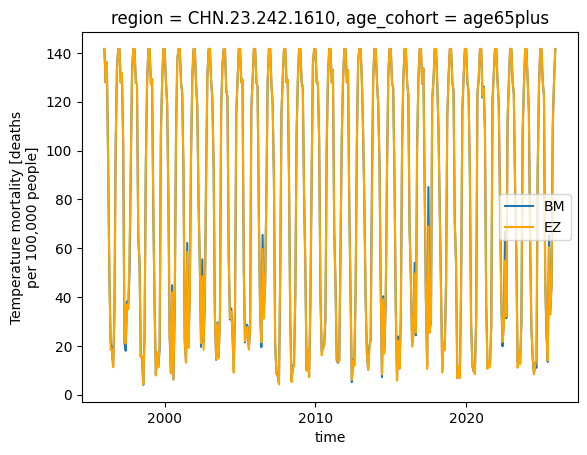

In [44]:
region_i = 7000
effect_bm['/baseline']['effect'].isel(region = region_i).sel(age_cohort = 'age65plus').median(dim = 'sample').plot(label = 'BM')

effect_ez['/baseline']['effect'].isel(region = region_i).sel(age_cohort = 'age65plus').median(dim = 'sample').plot(label = 'EZ', color = 'orange')
plt.legend()

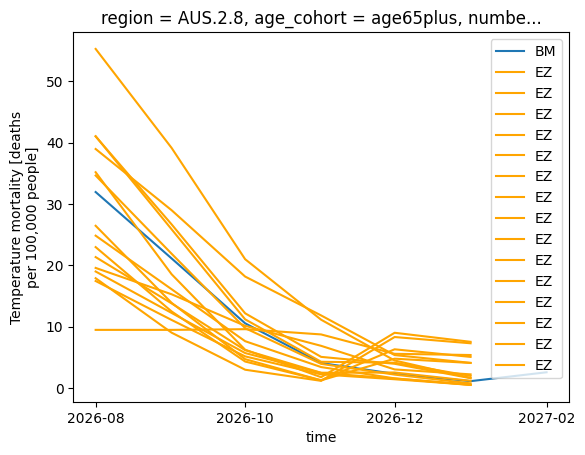

In [ ]:
region_i = 1000
effect_bm['/forecast']['effect'].isel(region = region_i, number = 10).sel(age_cohort = 'age65plus').plot(label = 'BM')
for i in range(15):
    effect_ez['/forecast']['effect'].isel(region = region_i, number = 10).sel(age_cohort = 'age65plus').sel(sample = i).plot(label = 'EZ', color = 'orange')
plt.legend()

In [41]:
impact_ez = analysis_utils.compute_impact(effect_ez, socioeconomics, ensemble = True, 
                                       baseline_period=baseline_period, 
                                       hotonly = "net", rate = False, age_weight = True,
                                       chunks = {'number': -1,'region': 'auto' })
impact_bm = analysis_utils.compute_impact(effect_bm, socioeconomics, ensemble = True,
                                        baseline_period=baseline_period,
                                        hotonly = "net", rate = False, age_weight = True,
                                        chunks = {'number': -1,'region': 'auto' })
q_diff = impact_ez-impact_bm
_polygons_impact = analysis_utils.xarray_to_gpd(q_diff.sum(dim = 'month').mean(dim = 'number'), _polygons)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


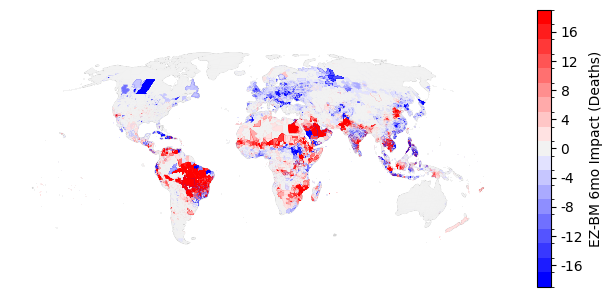

In [42]:
fig = analysis_utils.plot_single(
    _polygons_impact,
    col='age_weighted_impact',
    n_colors = 11,
    cm = 'bwr',
    sup_title=f"",
    cbar_label= "EZ-BM 6mo Impact (Deaths)",
)

# Number of Quantiles

In [23]:
EFFECTS_URI_100 = "gs://poreallas-public-20260605/v20260825/parsed/effects-q100.zarr"
EFFECTS_URI_20 = "gs://poreallas-public-20260605/v20260825/parsed/effects-q20.zarr"

In [24]:
effect_100 = xr.open_datatree(EFFECTS_URI_100,
                            engine="zarr", chunks={},
                            backend_kwargs={"storage_options": {"token": "anon"}})
effect_20 = xr.open_datatree(EFFECTS_URI_20,
                            engine="zarr", chunks={},
                            backend_kwargs={"storage_options": {"token": "anon"}})

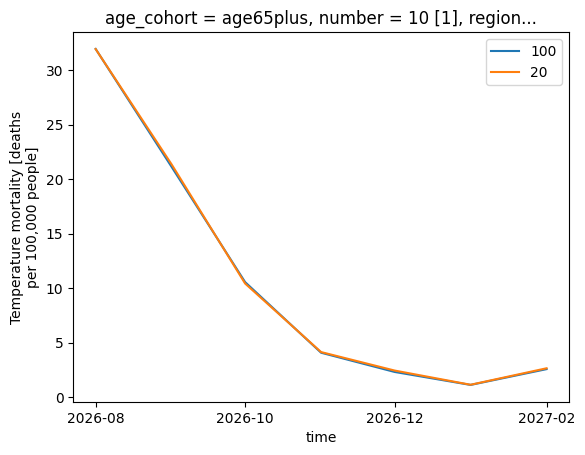

In [25]:
region_i = 1000
effect_100['/forecast']['effect'].isel(region = region_i, number = 10).sel(age_cohort = 'age65plus').plot(label = '100')
effect_20['/forecast']['effect'].isel(region = region_i, number = 10).sel(age_cohort = 'age65plus').plot(label = '20')
plt.legend()

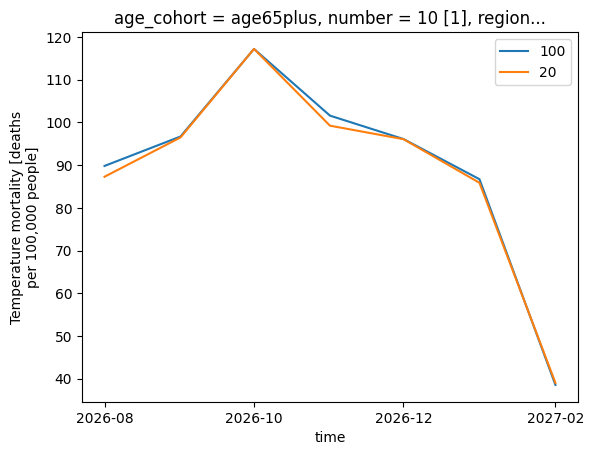

In [26]:
region_i = 10000
effect_100['/forecast']['effect'].isel(region = region_i, number = 10).sel(age_cohort = 'age65plus').plot(label = '100')
effect_20['/forecast']['effect'].isel(region = region_i, number = 10).sel(age_cohort = 'age65plus').plot(label = '20')
plt.legend()

In [ ]:
impact_100 = analysis_utils.compute_impact(effect_100, socioeconomics, ensemble = True, 
                                       baseline_period=baseline_period, 
                                       hotonly = "net", rate = False, age_weight = True,
                                       chunks = {'number': -1,'region': 'auto' })
impact_20 = analysis_utils.compute_impact(effect_20, socioeconomics, ensemble = True,
                                        baseline_period=baseline_period,
                                        hotonly = "net", rate = False, age_weight = True,
                                        chunks = {'number': -1,'region': 'auto' })
q_diff = impact_100-impact_20
_polygons_impact = analysis_utils.xarray_to_gpd(q_diff.sum(dim = 'month').mean(dim = 'number'), _polygons)

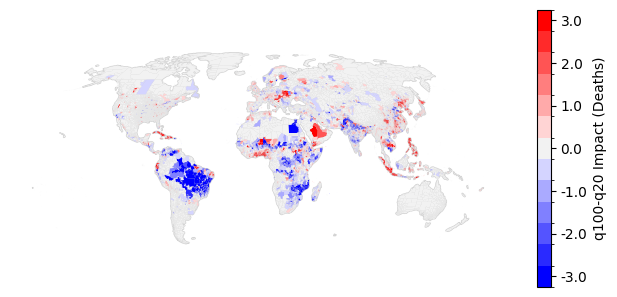

In [33]:
fig = analysis_utils.plot_single(
    _polygons_impact,
    col='age_weighted_impact',
    n_colors = 11,
    cm = 'bwr',
    sup_title=f"",
    cbar_label= "q100-q20 Impact (Deaths)",
)